# 04 — Evaluación del pipeline completo

**Proyecto:** Skin Lesion Analysis  
**Repositorio:** https://github.com/Jesusrodriguezf90/skin-lesion-analysis  
**Fase:** Evaluación del pipeline U-Net → EfficientNet-B0

---

Este notebook evalúa el pipeline completo encadenando los dos modelos entrenados:
U-Net genera pseudo-máscaras sobre las imágenes de Task 3 (HAM10000) y
EfficientNet-B0 clasifica sobre la región segmentada.

La comparativa principal es:
- **Modo A:** clasificación sobre imagen completa (sin segmentación)
- **Modo B:** clasificación sobre región segmentada por U-Net (pipeline completo)

El objetivo es medir si la segmentación previa mejora o degrada la clasificación.

In [16]:
"""
Notebook: 04_evaluation.ipynb

Objetivo:
    Evaluar el pipeline completo U-Net → EfficientNet-B0 usando pseudo-máscaras
    generadas por U-Net sobre las 10.015 imágenes de HAM10000 (Task 3).

    Comparativa principal:
    A) Clasificación sobre imagen completa — sin segmentación
    B) Clasificación sobre región segmentada por U-Net — pipeline real

    La diferencia A vs B mide el impacto real de la segmentación previa
    sobre el rendimiento del clasificador.

Enfoque metodológico:
    No existe un dataset público con imagen + máscara + las 7 etiquetas de
    ISIC 2018 que no se solape con los datos de entrenamiento de alguno de
    los dos modelos. El enfoque estándar en la literatura para este escenario
    es usar pseudo-máscaras generadas por el modelo de segmentación ya
    entrenado sobre el conjunto de clasificación. Este enfoque está respaldado
    por trabajos como Collaborative Learning (PMC10001355) y Sequential
    Segmentation-Classification (MDPI 2024).

Limitaciones conocidas:
    - EfficientNet fue entrenado con las imágenes de Task 3 — no son datos
      completamente nuevos para el clasificador. La comparativa A vs B mide
      el impacto de la segmentación, no el rendimiento absoluto en datos nuevos.
    - U-Net fue entrenado con Task 1 (imágenes distintas a Task 3) — las
      pseudo-máscaras son predicciones sobre una distribución de imágenes
      que U-Net no vio durante el entrenamiento.
    - La literatura reporta que eliminar completamente el fondo puede degradar
      el rendimiento (Hasan et al., 2020). El enmascarado neutro (fondo a
      media ImageNet) minimiza este efecto.

Fuente de datos:
    ISIC 2018 Task 3 / HAM10000 — 10.015 imágenes + etiquetas (7 clases)
    https://challenge.isic-archive.com/data/#2018

Autor:   Jesús Rodríguez
Fecha:   2026-06-05
Versión: 1.0.0
"""

'\nNotebook: 04_evaluation.ipynb\n\nObjetivo:\n    Evaluar el pipeline completo U-Net → EfficientNet-B0 usando pseudo-máscaras\n    generadas por U-Net sobre las 10.015 imágenes de HAM10000 (Task 3).\n\n    Comparativa principal:\n    A) Clasificación sobre imagen completa — sin segmentación\n    B) Clasificación sobre región segmentada por U-Net — pipeline real\n\n    La diferencia A vs B mide el impacto real de la segmentación previa\n    sobre el rendimiento del clasificador.\n\nEnfoque metodológico:\n    No existe un dataset público con imagen + máscara + las 7 etiquetas de\n    ISIC 2018 que no se solape con los datos de entrenamiento de alguno de\n    los dos modelos. El enfoque estándar en la literatura para este escenario\n    es usar pseudo-máscaras generadas por el modelo de segmentación ya\n    entrenado sobre el conjunto de clasificación. Este enfoque está respaldado\n    por trabajos como Collaborative Learning (PMC10001355) y Sequential\n    Segmentation-Classification (M

## 1. Configuración del entorno

In [17]:
import os

IN_KAGGLE = os.path.exists("/kaggle/input")
print(f"Entorno detectado: {"Kaggle" if IN_KAGGLE else "local"}")

Entorno detectado: Kaggle


In [18]:
import sys
import torch

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


## 2. Instalación de dependencias

In [19]:
%pip install segmentation-models-pytorch timm albumentations -q

Note: you may need to restart the kernel to use updated packages.


In [20]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

print("Dependencias importadas correctamente")

Dependencias importadas correctamente


## 3. Reproducibilidad y configuración global

In [21]:
SEED = 42

def set_seed(seed: int) -> None:
    """Fija la semilla en todos los generadores aleatorios del stack.

    Args:
        seed: Valor entero de la semilla.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

CLASES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
NOMBRES_CLASES = {
    "MEL"  : "Melanoma",
    "NV"   : "Melanocytic nevus",
    "BCC"  : "Basal cell carcinoma",
    "AKIEC": "Actinic keratosis",
    "BKL"  : "Benign keratosis",
    "DF"   : "Dermatofibroma",
    "VASC" : "Vascular lesion",
}

IMG_SIZE = 256
BATCH    = 32
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


## 4. Definición de rutas

In [22]:
if IN_KAGGLE:
    DIR_INPUT  = Path("/kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion")
    DIR_OUTPUT = Path("/kaggle/working")
else:
    DIR_INPUT  = Path("data/raw")
    DIR_OUTPUT = Path("data/processed")

# Task 3 — imágenes con etiquetas (HAM10000)
DIR_IMAGENES_T3 = DIR_INPUT / "ISIC2018_Task3_Training_Input" / "ISIC2018_Task3_Training_Input"
RUTA_CSV        = DIR_INPUT / "ISIC2018_Task3_Training_GroundTruth.csv"

DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

assert DIR_IMAGENES_T3.exists(), f"No se encontró: {DIR_IMAGENES_T3}"
assert RUTA_CSV.exists(),        f"No se encontró: {RUTA_CSV}"

imagenes_t3 = sorted(DIR_IMAGENES_T3.glob("*.jpg"))
print(f"Imágenes Task 3 : {len(imagenes_t3)}")

Imágenes Task 3 : 10015


## 5. Carga de modelos desde HF Hub

In [23]:
from huggingface_hub import hf_hub_download
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")

print("Descargando modelos desde HF Hub...")

ruta_unet = hf_hub_download(
    repo_id  = "Jesusrodriguezf90/unet-resnet34-isic2018-segmentation",
    filename = "best_unet_resnet34.pth",
    token    = HF_TOKEN,
)
ruta_effnet = hf_hub_download(
    repo_id  = "Jesusrodriguezf90/efficientnet-b0-isic2018-classification",
    filename = "best_efficientnet_b0.pth",
    token    = HF_TOKEN,
)

print(f"U-Net        : {ruta_unet}")
print(f"EfficientNet : {ruta_effnet}")

Descargando modelos desde HF Hub...
U-Net        : /root/.cache/huggingface/hub/models--Jesusrodriguezf90--unet-resnet34-isic2018-segmentation/snapshots/03d64aeb97ef50ae1b3a68224645c7eeb081a61a/best_unet_resnet34.pth
EfficientNet : /root/.cache/huggingface/hub/models--Jesusrodriguezf90--efficientnet-b0-isic2018-classification/snapshots/636cae706dcf27dbede898f8133c818588efc772/best_efficientnet_b0.pth


In [24]:
# Carga del modelo U-Net entrenado con las 2.594 imágenes de Task 1 (02_segmentation).
# Los pesos descargados desde HF Hub son los que aprendieron a segmentar lesiones
# dermoscópicas — se usan aquí para generar pseudo-máscaras sobre Task 3.
# Reconstruir U-Net — misma arquitectura que en 02_segmentation
unet = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = None,
    in_channels     = 3,
    classes         = 1,
    activation      = None,
).to(DEVICE)
unet.load_state_dict(torch.load(ruta_unet, map_location=DEVICE))
unet.eval()

# Reconstruir EfficientNet-B0 — misma arquitectura que en 03_classification
effnet = timm.create_model(
    "efficientnet_b0",
    pretrained  = False,
    num_classes = 7,
).to(DEVICE)
effnet.load_state_dict(torch.load(ruta_effnet, map_location=DEVICE))
effnet.eval()

print("Modelos cargados correctamente")

Modelos cargados correctamente


## 6. Preparación del dataset y transforms

In [25]:
# Carga del CSV y construcción del DataFrame
df = pd.read_csv(RUTA_CSV)
df["label"] = df[CLASES].values.argmax(axis=1)
df["ruta"]  = df["image"].apply(lambda x: DIR_IMAGENES_T3 / f"{x}.jpg")

# Verificar que todas las imágenes existen
n_faltantes = df["ruta"].apply(lambda p: not p.exists()).sum()
print(f"Imágenes faltantes: {n_faltantes}")
print(f"Total imágenes    : {len(df)}")

Imágenes faltantes: 0
Total imágenes    : 10015


In [26]:
# Pipeline de preprocesamiento — idéntico al entrenamiento
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Media de ImageNet en espacio de píxeles — para enmascarado neutro
# El fondo se pone a la media de ImageNet en lugar de a cero para que
# el modelo normalizado no interprete el fondo como información relevante
MEAN_IMG = np.array([0.485, 0.456, 0.406]) * 255


class HAM10000EvalDataset(Dataset):
    """Dataset PyTorch para evaluación sobre HAM10000.

    Args:
        df:        DataFrame con columnas "ruta" y "label".
        transform: Pipeline de Albumentations.
    """

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple:
        ruta  = self.df.loc[idx, "ruta"]
        label = self.df.loc[idx, "label"]
        img   = np.array(Image.open(ruta).convert("RGB"))

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)


ds_eval = HAM10000EvalDataset(df, transform)
dl_eval = DataLoader(ds_eval, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches de evaluación: {len(dl_eval)}")

Batches de evaluación: 313


## 7. Generación de pseudo-máscaras con U-Net

In [27]:
# U-Net genera pseudo-máscaras sobre las 10.015 imágenes de Task 3
# Estas imágenes son distintas a Task 1 — U-Net no las vio durante el entrenamiento
# Las pseudo-máscaras se guardan en memoria para reutilizarlas en la comparativa
print("Generando pseudo-máscaras con U-Net...")

todas_mascaras = []

with torch.no_grad():
    for i, (imgs, _) in enumerate(dl_eval):
        imgs = imgs.to(DEVICE)
        pred = torch.sigmoid(unet(imgs))  # (B, 1, H, W)
        mask = (pred > 0.5).float().squeeze(1).cpu().numpy()  # (B, H, W)
        todas_mascaras.append(mask)

        if (i + 1) % 50 == 0:
            print(f"  Procesados {(i+1)*BATCH}/{len(df)} imágenes")

todas_mascaras = np.concatenate(todas_mascaras, axis=0)  # (10015, H, W)

# Estadísticas de cobertura de las pseudo-máscaras
cobertura_media = todas_mascaras.mean(axis=(1, 2)).mean()
print(f"\nPseudo-máscaras generadas: {len(todas_mascaras)}")
print(f"Cobertura media          : {cobertura_media*100:.1f}%")
print(f"(referencia Task 1: 21.7%)")

Generando pseudo-máscaras con U-Net...
  Procesados 1600/10015 imágenes
  Procesados 3200/10015 imágenes
  Procesados 4800/10015 imágenes
  Procesados 6400/10015 imágenes
  Procesados 8000/10015 imágenes
  Procesados 9600/10015 imágenes

Pseudo-máscaras generadas: 10015
Cobertura media          : 27.7%
(referencia Task 1: 21.7%)


## 8. Evaluación comparativa A vs B

In [28]:
# Dataset que devuelve imagen completa e imagen enmascarada en paralelo
# El enmascarado se aplica en __getitem__ — los workers de DataLoader
# paralelizan la carga y el enmascarado sin overhead de Python por iteración
class HAM10000MaskedDataset(Dataset):
    """Dataset para evaluación comparativa A vs B.

    Args:
        df:        DataFrame con columnas "ruta" y "label".
        mascaras:  Array (N, H, W) con pseudo-máscaras pre-generadas por U-Net.
        transform: Pipeline de Albumentations.
        img_size:  Resolución de las máscaras (debe coincidir con IMG_SIZE).

    Notes:
        El fondo se pone a la media de ImageNet (no a cero) para que el
        modelo normalizado no interprete el fondo como señal relevante.
    """

    MEAN_IMG = np.array([0.485, 0.456, 0.406]) * 255

    def __init__(self, df, mascaras, transform, img_size):
        self.df        = df.reset_index(drop=True)
        self.mascaras  = mascaras
        self.transform = transform
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ruta  = self.df.loc[idx, "ruta"]
        label = self.df.loc[idx, "label"]
        mask  = self.mascaras[idx]  # (H, W) — ya a resolución IMG_SIZE

        img_np  = np.array(Image.open(ruta).convert("RGB"))
        img_256 = np.array(Image.fromarray(img_np).resize((self.img_size, self.img_size)))

        # Imagen enmascarada — fondo a media ImageNet para neutralidad semántica
        img_masked = img_256.copy().astype(np.float32)
        for c in range(3):
            img_masked[:, :, c] = np.where(mask > 0, img_256[:, :, c], self.MEAN_IMG[c])
        img_masked = img_masked.astype(np.uint8)

        t_img    = self.transform(image=img_np)["image"]
        t_masked = self.transform(image=img_masked)["image"]

        return t_img, t_masked, torch.tensor(label, dtype=torch.long)


ds_masked = HAM10000MaskedDataset(df, todas_mascaras, transform, IMG_SIZE)
dl_masked = DataLoader(
    ds_masked,
    batch_size  = BATCH,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True,
)

print(f"Dataset de evaluación: {len(ds_masked)} imágenes")
print(f"Batches             : {len(dl_masked)}")

Dataset de evaluación: 10015 imágenes
Batches             : 313


In [29]:
# Inferencia vectorizada — ambos modos en el mismo batch
# GPU procesa batches completos de 32 imágenes sin overhead de Python por iteración
preds_A, preds_B = [], []
probs_A, probs_B = [], []
labels_reales    = []

print("Evaluando pipeline completo...")

with torch.no_grad():
    for i, (imgs, imgs_masked, labels) in enumerate(dl_masked):
        imgs        = imgs.to(DEVICE)
        imgs_masked = imgs_masked.to(DEVICE)

        # Modo A: imagen completa → EfficientNet
        probs_a = torch.softmax(effnet(imgs),        dim=1).cpu().numpy()
        # Modo B: imagen enmascarada → EfficientNet
        probs_b = torch.softmax(effnet(imgs_masked), dim=1).cpu().numpy()

        preds_A.extend(probs_a.argmax(axis=1))
        preds_B.extend(probs_b.argmax(axis=1))
        probs_A.extend(probs_a)
        probs_B.extend(probs_b)
        labels_reales.extend(labels.numpy())

        if (i + 1) % 50 == 0:
            print(f"  Batch {i+1}/{len(dl_masked)}")

preds_A       = np.array(preds_A)
preds_B       = np.array(preds_B)
probs_A       = np.array(probs_A)
probs_B       = np.array(probs_B)
labels_reales = np.array(labels_reales)

print("Evaluación completada")

Evaluando pipeline completo...
  Batch 50/313
  Batch 100/313
  Batch 150/313
  Batch 200/313
  Batch 250/313
  Batch 300/313
Evaluación completada


In [30]:
def calcular_metricas(preds, probs, labels, nombre):
    """Calcula F1 macro, F1 weighted y AUC macro.

    Args:
        preds:  Predicciones duras (N,).
        probs:  Probabilidades softmax (N, 7).
        labels: Etiquetas ground truth (N,).
        nombre: Nombre del modo para el informe.

    Returns:
        Diccionario con métricas calculadas.
    """
    f1_macro  = f1_score(labels, preds, average="macro",    zero_division=0)
    f1_weight = f1_score(labels, preds, average="weighted", zero_division=0)
    auc       = roc_auc_score(labels, probs, multi_class="ovr", average="macro")

    print(f"\n── {nombre} ──")
    print(f"  F1 macro   : {f1_macro:.4f}")
    print(f"  F1 weighted: {f1_weight:.4f}")
    print(f"  AUC macro  : {auc:.4f}")

    return {"f1_macro": f1_macro, "f1_weighted": f1_weight, "auc": auc}


print("=" * 60)
print("COMPARATIVA A vs B — PIPELINE COMPLETO")
print("=" * 60)

met_A = calcular_metricas(preds_A, probs_A, labels_reales, "A) Sin segmentación")
met_B = calcular_metricas(preds_B, probs_B, labels_reales, "B) Con pseudo-máscara U-Net")

print("\n── Diferencia B - A ──")
print(f"  ΔF1 macro : {met_B['f1_macro'] - met_A['f1_macro']:+.4f}")
print(f"  ΔAUC      : {met_B['auc'] - met_A['auc']:+.4f}")
print("=" * 60)

COMPARATIVA A vs B — PIPELINE COMPLETO

── A) Sin segmentación ──
  F1 macro   : 0.8411
  F1 weighted: 0.8517
  AUC macro  : 0.9920

── B) Con pseudo-máscara U-Net ──
  F1 macro   : 0.3554
  F1 weighted: 0.3721
  AUC macro  : 0.8288

── Diferencia B - A ──
  ΔF1 macro : -0.4858
  ΔAUC      : -0.1632


## 9. Visualización comparativa A vs B

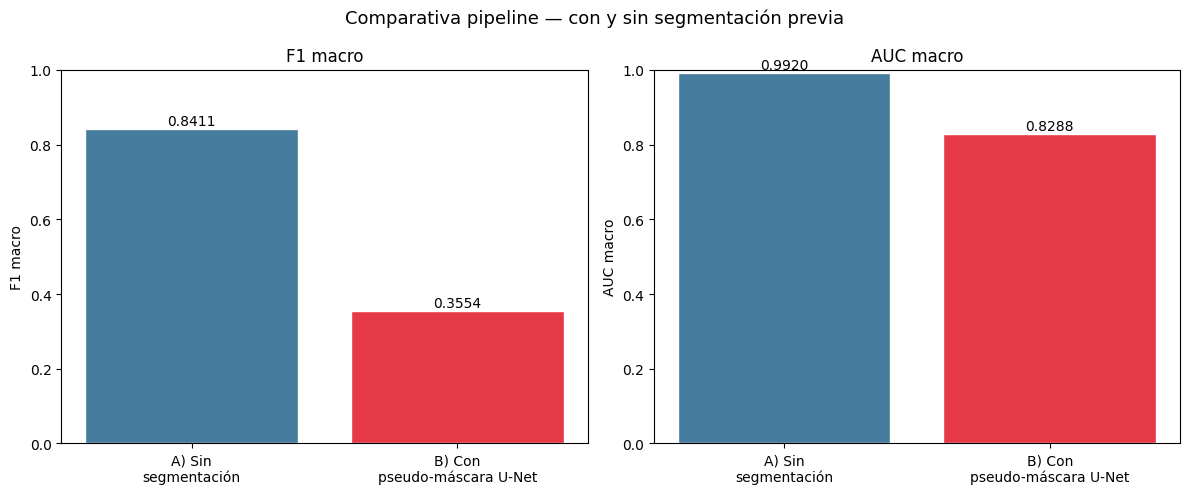

In [31]:
# Gráfico de barras comparando F1 y AUC en ambos modos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modos   = ["A) Sin\nsegmentación", "B) Con\npseudo-máscara U-Net"]
f1_vals = [met_A["f1_macro"], met_B["f1_macro"]]
auc_vals= [met_A["auc"],      met_B["auc"]]
colores = ["#457b9d", "#e63946"]

axes[0].bar(modos, f1_vals, color=colores, edgecolor="white")
axes[0].set_title("F1 macro")
axes[0].set_ylabel("F1 macro")
axes[0].set_ylim(0, 1)
for i, v in enumerate(f1_vals):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

axes[1].bar(modos, auc_vals, color=colores, edgecolor="white")
axes[1].set_title("AUC macro")
axes[1].set_ylabel("AUC macro")
axes[1].set_ylim(0, 1)
for i, v in enumerate(auc_vals):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)

plt.suptitle("Comparativa pipeline — con y sin segmentación previa", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "comparativa_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Informe detallado por clase

In [32]:
# Informe de clasificación para el modo A (referencia)
nombres = [f"{c} ({NOMBRES_CLASES[c]})" for c in CLASES]

print("── Modo A: sin segmentación (referencia) ──")
print(classification_report(labels_reales, preds_A, target_names=nombres, zero_division=0))

── Modo A: sin segmentación (referencia) ──
                            precision    recall  f1-score   support

            MEL (Melanoma)       0.56      0.95      0.71      1113
    NV (Melanocytic nevus)       0.99      0.79      0.88      6705
BCC (Basal cell carcinoma)       0.75      0.99      0.85       514
 AKIEC (Actinic keratosis)       0.88      0.96      0.92       327
    BKL (Benign keratosis)       0.73      0.96      0.83      1099
       DF (Dermatofibroma)       0.75      0.98      0.85       115
    VASC (Vascular lesion)       0.75      1.00      0.86       142

                  accuracy                           0.84     10015
                 macro avg       0.77      0.95      0.84     10015
              weighted avg       0.89      0.84      0.85     10015



In [33]:
# Informe de clasificación para el modo B (pipeline completo)
print("── Modo B: con pseudo-máscara U-Net ──")
print(classification_report(labels_reales, preds_B, target_names=nombres, zero_division=0))

── Modo B: con pseudo-máscara U-Net ──
                            precision    recall  f1-score   support

            MEL (Melanoma)       0.19      0.54      0.29      1113
    NV (Melanocytic nevus)       0.93      0.25      0.39      6705
BCC (Basal cell carcinoma)       0.58      0.29      0.39       514
 AKIEC (Actinic keratosis)       0.87      0.27      0.41       327
    BKL (Benign keratosis)       0.20      0.75      0.32      1099
       DF (Dermatofibroma)       0.14      0.52      0.22       115
    VASC (Vascular lesion)       0.38      0.63      0.47       142

                  accuracy                           0.35     10015
                 macro avg       0.47      0.47      0.36     10015
              weighted avg       0.73      0.35      0.37     10015



## 11. Análisis de errores — impacto por clase

In [34]:
# F1 por clase en ambos modos — identifica qué clases se benefician
# o perjudican más con la segmentación previa
f1_A_por_clase = f1_score(labels_reales, preds_A, average=None, zero_division=0)
f1_B_por_clase = f1_score(labels_reales, preds_B, average=None, zero_division=0)
delta_f1       = f1_B_por_clase - f1_A_por_clase

print("=" * 60)
print("IMPACTO DE LA SEGMENTACIÓN POR CLASE")
print("=" * 60)
for i, clase in enumerate(CLASES):
    signo = "+" if delta_f1[i] >= 0 else ""
    print(f"  {clase:<6} {NOMBRES_CLASES[clase]:<25} "
          f"A:{f1_A_por_clase[i]:.3f}  B:{f1_B_por_clase[i]:.3f}  "
          f"Δ:{signo}{delta_f1[i]:.3f}")
print("=" * 60)

IMPACTO DE LA SEGMENTACIÓN POR CLASE
  MEL    Melanoma                  A:0.705  B:0.286  Δ:-0.419
  NV     Melanocytic nevus         A:0.876  B:0.392  Δ:-0.484
  BCC    Basal cell carcinoma      A:0.850  B:0.389  Δ:-0.461
  AKIEC  Actinic keratosis         A:0.918  B:0.407  Δ:-0.510
  BKL    Benign keratosis          A:0.830  B:0.319  Δ:-0.511
  DF     Dermatofibroma            A:0.853  B:0.218  Δ:-0.635
  VASC   Vascular lesion           A:0.855  B:0.475  Δ:-0.380


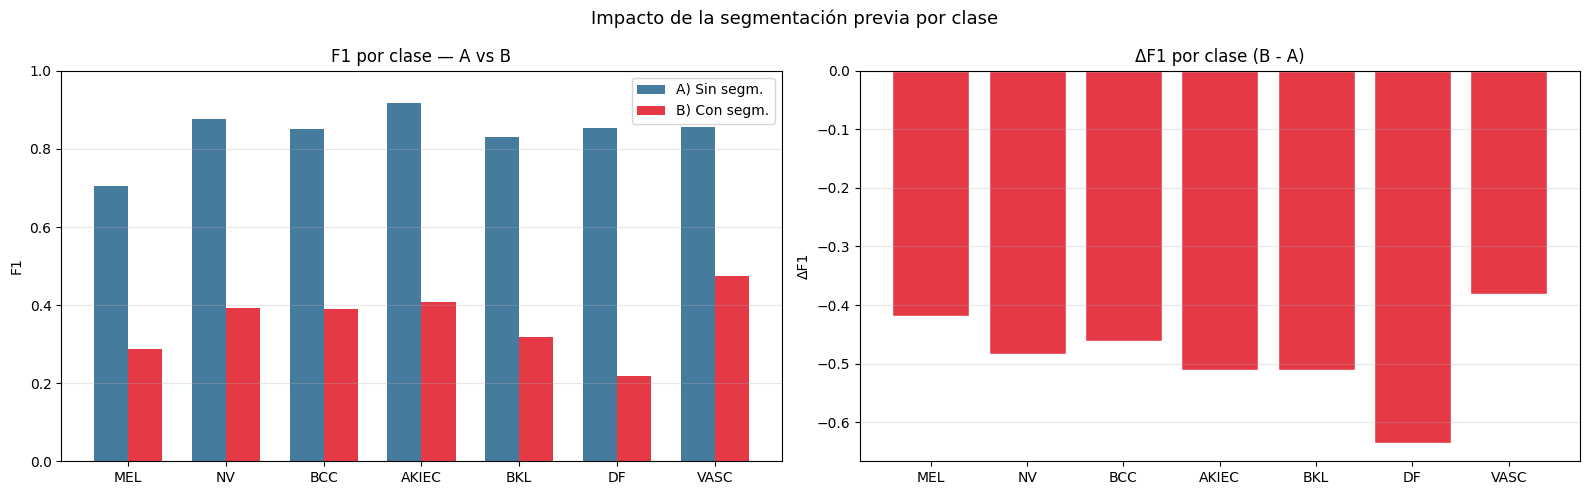

In [35]:
# Visualización del impacto por clase
x = np.arange(len(CLASES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 por clase — comparativa
axes[0].bar(x - width/2, f1_A_por_clase, width, label="A) Sin segm.", color="#457b9d")
axes[0].bar(x + width/2, f1_B_por_clase, width, label="B) Con segm.", color="#e63946")
axes[0].set_title("F1 por clase — A vs B")
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASES)
axes[0].set_ylabel("F1")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Delta F1 por clase
colores_delta = ["#2a9d8f" if d >= 0 else "#e63946" for d in delta_f1]
axes[1].bar(CLASES, delta_f1, color=colores_delta, edgecolor="white")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("ΔF1 por clase (B - A)")
axes[1].set_ylabel("ΔF1")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Impacto de la segmentación previa por clase", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "impacto_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Visualización de predicciones

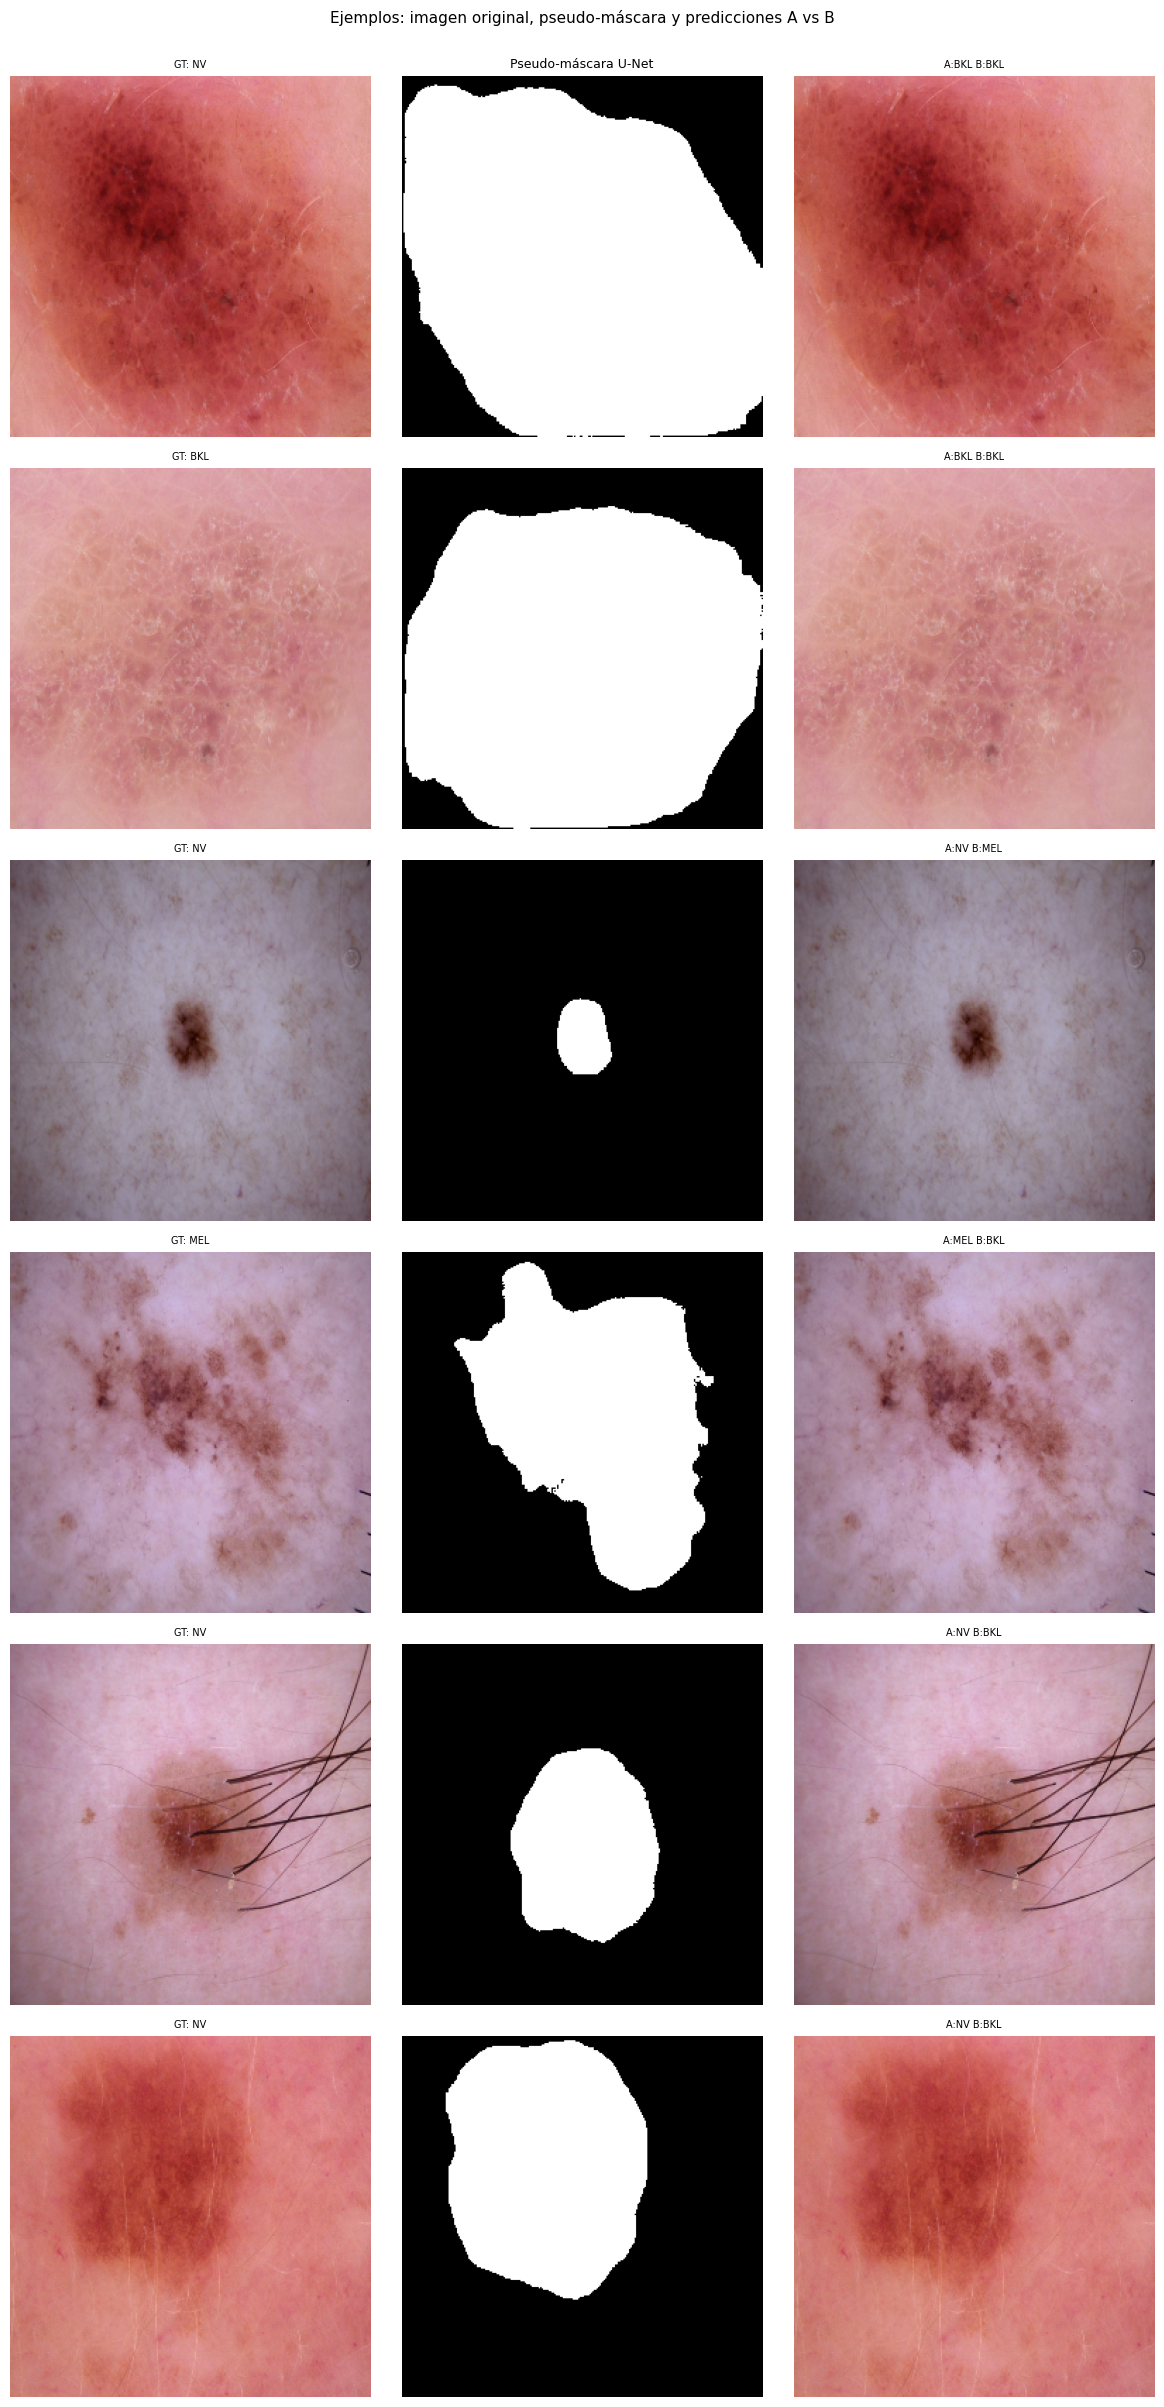

In [36]:
# Visualización de 6 ejemplos aleatorios con imagen original,
# pseudo-máscara U-Net y predicciones de ambos modos
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

random.seed(0)
indices_viz = random.sample(list(range(len(ds_masked))), 6)

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
axes[0, 0].set_title("Imagen original", fontsize=9)
axes[0, 1].set_title("Pseudo-máscara U-Net", fontsize=9)
axes[0, 2].set_title("A (sin) vs B (con)", fontsize=9)

effnet.eval()
with torch.no_grad():
    for i, idx in enumerate(indices_viz):
        t_img, t_masked, label = ds_masked[idx]

        # Predicciones
        pred_A = effnet(t_img.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        pred_B = effnet(t_masked.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()

        # Desnormalizar imagen
        img_np = np.clip(t_img.permute(1, 2, 0).numpy() * STD + MEAN, 0, 1)

        # Máscara
        mask_np = todas_mascaras[idx]

        # Color del título: verde=correcto, rojo=incorrecto
        color_A = "green" if pred_A == label.item() else "red"
        color_B = "green" if pred_B == label.item() else "red"

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"GT: {CLASES[label.item()]}", fontsize=7)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img_np)
        axes[i, 2].set_title(
            f"A:{CLASES[pred_A]} B:{CLASES[pred_B]}",
            fontsize=7,
            color="black"
        )
        axes[i, 2].axis("off")

plt.suptitle("Ejemplos: imagen original, pseudo-máscara y predicciones A vs B",
             fontsize=11, y=1.001)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "ejemplos_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Resumen y conclusiones

In [37]:
# Resumen del experimento con análisis crítico de los resultados
print("=" * 65)
print("RESUMEN — EVALUACIÓN DEL PIPELINE COMPLETO")
print("=" * 65)
print(f"  Imágenes evaluadas       : {len(labels_reales)}")
print(f"  Modo A — F1 macro        : {met_A['f1_macro']:.4f}")
print(f"  Modo A — AUC macro       : {met_A['auc']:.4f}")
print(f"  Modo B — F1 macro        : {met_B['f1_macro']:.4f}")
print(f"  Modo B — AUC macro       : {met_B['auc']:.4f}")
print(f"  ΔF1 macro (B - A)        : {met_B['f1_macro'] - met_A['f1_macro']:+.4f}")
print("=" * 65)
print()
print("Conclusiones:")
print("  - La segmentación previa degrada el rendimiento del clasificador")
print("  - Causa 1: distribution shift — U-Net entrenado con Task 1,")
print("    genera pseudo-máscaras sobre Task 3 (distribución diferente)")
print("  - Causa 2: EfficientNet usa contexto de piel sana para clasificar")
print("    — eliminarlo con la máscara elimina información diagnóstica")
print("  - Resultado consistente con Hasan et al. (2020): eliminar")
print("    completamente el fondo degrada el rendimiento de clasificación")
print()
print("Trabajo futuro:")
print("  - Entrenar U-Net y EfficientNet con el mismo dataset (HAM10000")
print("    con máscaras anotadas) para eliminar el distribution shift")
print("  - Evaluar enmascarado parcial (fondo atenuado, no eliminado)")
print("=" * 65)

RESUMEN — EVALUACIÓN DEL PIPELINE COMPLETO
  Imágenes evaluadas       : 10015
  Modo A — F1 macro        : 0.8411
  Modo A — AUC macro       : 0.9920
  Modo B — F1 macro        : 0.3554
  Modo B — AUC macro       : 0.8288
  ΔF1 macro (B - A)        : -0.4858

Conclusiones:
  - La segmentación previa degrada el rendimiento del clasificador
  - Causa 1: distribution shift — U-Net entrenado con Task 1,
    genera pseudo-máscaras sobre Task 3 (distribución diferente)
  - Causa 2: EfficientNet usa contexto de piel sana para clasificar
    — eliminarlo con la máscara elimina información diagnóstica
  - Resultado consistente con Hasan et al. (2020): eliminar
    completamente el fondo degrada el rendimiento de clasificación

Trabajo futuro:
  - Entrenar U-Net y EfficientNet con el mismo dataset (HAM10000
    con máscaras anotadas) para eliminar el distribution shift
  - Evaluar enmascarado parcial (fondo atenuado, no eliminado)
